# Gender Recognition from Audio

In [1]:
# ── Cell 1: Install & Imports ─────────────────────────────────────────────────
!pip install librosa xgboost scikit-learn imbalanced-learn joblib matplotlib seaborn soundfile resampy -q
print('✅ All libraries installed.')

from google.colab import drive
import zipfile, os
import numpy as np
import librosa
import joblib
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ── FIX 1: Define colour palette (was MISSING in v3) ──────────────────────────
C = {
    'lr':     '#4FC3F7',   # light blue  – Logistic Regression
    'svm':    '#EF5350',   # red         – SVM
    'xgb':    '#FFD54F',   # amber       – XGBoost
    'male':   '#42A5F5',   # blue        – Male bars
    'female': '#EC407A',   # pink        – Female bars
}

drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 8.9 MB/s eta 0:00:00
✅ All libraries installed.
Mounted at /content/drive


In [ ]:
# ── Cell 2: Extract ZIP ───────────────────────────────────────────────────────
# ── FIX 2: Path updated to match your Drive screenshot ───────────────────────
# Your screenshot shows:  Shared with me > ML 2026 > data > data  (folder)
# The zip lives one level up. Adjust the line below if needed.
zip_path     = '/content/drive/MyDrive/ML 2026/data.zip'   # ← change if zip is elsewhere
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

# Safety check — print exactly what path is being used
print(f'📂 zip_path     : {zip_path}')
print(f'📂 extract_path : {extract_path}')
print(f'🔎 zip exists?  : {os.path.exists(zip_path)}')

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f'ZIP not found at: {zip_path}\n'
        'If your Drive is shared, try:\n'
        "  zip_path = '/content/drive/Shareddrives/<drive-name>/ML 2026/data.zip'"
    )

print('⏳ Extracting zip...')
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print('✅ Extraction complete!')

📂 zip_path     : /content/drive/MyDrive/ML 2026/data.zip
📂 extract_path : /content/dataset
🔎 zip exists?  : True
⏳ Extracting zip...
✅ Extraction complete!


In [ ]:
# ── Cell 3: Locate male / female folders ──────────────────────────────────────
print('\n🔍 Searching for male/female folders...')
male_path = female_path = None
for root, dirs, files in os.walk(extract_path):
    basename = os.path.basename(root).lower()
    if basename == 'male'   and male_path   is None: male_path   = root
    if basename == 'female' and female_path is None: female_path = root

# ── FIX 3: Print discovered paths so you can verify ──────────────────────────
print(f'   male_path   → {male_path}')
print(f'   female_path → {female_path}')

if male_path is None or female_path is None:
    # Dump the tree so you can see actual folder names
    print('\n📁 Folder tree inside extract_path:')
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, '').count(os.sep)
        print('  ' * level + os.path.basename(root) + '/')
    raise FileNotFoundError(
        'Could not find male/female folders automatically.\n'
        'Set male_path and female_path manually from the tree above.'
    )

print(f'\n✅ Found {len([f for f in os.listdir(male_path)   if f.endswith(".wav")])} male   .wav files')
print(f'✅ Found {len([f for f in os.listdir(female_path) if f.endswith(".wav")])} female .wav files')


🔍 Searching for male/female folders...
   male_path   → /content/dataset/data/male
   female_path → /content/dataset/data/female

✅ Found 10380 male   .wav files
✅ Found 5768 female .wav files


In [ ]:
# ── Cell 4: Feature Extraction ────────────────────────────────────────────────
def extract_features(file_path, duration=3):
    audio, sr = librosa.load(file_path, duration=duration, res_type='kaiser_fast')
    mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    chroma    = librosa.feature.chroma_stft(y=audio, sr=sr)
    zcr       = np.mean(librosa.feature.zero_crossing_rate(audio))
    centroid  = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    rolloff   = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
    rms       = np.mean(librosa.feature.rms(y=audio))
    return np.hstack([
        np.mean(mfcc.T,   axis=0),
        np.mean(chroma.T, axis=0),
        [zcr, centroid, rolloff, rms]
    ])

male_files   = [f for f in os.listdir(male_path)   if f.endswith('.wav')]
female_files = [f for f in os.listdir(female_path) if f.endswith('.wav')]

X, y, failed = [], [], 0
for label, folder, files in [(0, male_path, male_files), (1, female_path, female_files)]:
    print(f'⏳ Extracting {"MALE" if label==0 else "FEMALE"} features ({len(files)} files)...')
    for file in files:
        try:
            X.append(extract_features(os.path.join(folder, file)))
            y.append(label)
        except Exception as e:
            failed += 1
            if failed <= 3: print(f'  ⚠️ Failed on {file}: {e}')

X, y = np.array(X), np.array(y)
print(f'\n✅ Done! Feature matrix shape: {X.shape} | Failed files: {failed}')

⏳ Extracting MALE features (10380 files)...
⏳ Extracting FEMALE features (5768 files)...

✅ Done! Feature matrix shape: (16148, 56) | Failed files: 0


In [ ]:
# ── Cell 5: Train/Test Split → SMOTE → Scaling ───────────────────────────────
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_raw, y_train_raw)

# Scale AFTER SMOTE — fit on train, transform both splits
scaler    = StandardScaler()
X_train   = scaler.fit_transform(X_train_bal)
X_test_sc = scaler.transform(X_test)          # ← scaled test set (used in ALL predictions below)

# XGBoost class-weight safety net
scale_pos_weight = np.sum(y_train_bal == 0) / np.sum(y_train_bal == 1)

print(f'Train size (after SMOTE): {X_train.shape[0]} | Test size: {X_test_sc.shape[0]}')
print(f'Class balance after SMOTE → Male: {np.sum(y_train_bal==0)} | Female: {np.sum(y_train_bal==1)}')

Train size (after SMOTE): 16608 | Test size: 3230
Class balance after SMOTE → Male: 8304 | Female: 8304


In [ ]:
# ── Cell 6: Train Models ──────────────────────────────────────────────────────
print('🔵 Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train_bal)
print('   ✅ Done.')

print('🔴 Training SVM (RBF)...')
svm_model = SVC(kernel='rbf', C=10, probability=True, class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train_bal)
print('   ✅ Done.')

print('🟡 Training XGBoost...')
xgb_model = XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight,
                           random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train_bal)
print('   ✅ Done.')

# ── FIX 4: Generate predictions & probabilities (MISSING in v3) ───────────────
# All predictions use X_test_sc (scaled) — NOT the raw X_test
lr_pred   = lr_model.predict(X_test_sc)
svm_pred  = svm_model.predict(X_test_sc)
xgb_pred  = xgb_model.predict(X_test_sc)

lr_proba  = lr_model.predict_proba(X_test_sc)[:, 1]
svm_proba = svm_model.predict_proba(X_test_sc)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test_sc)[:, 1]

print('\n✅ Predictions and probabilities ready.')

🔵 Training Logistic Regression...
   ✅ Done.
🔴 Training SVM (RBF)...
   ✅ Done.
🟡 Training XGBoost...
   ✅ Done.

✅ Predictions and probabilities ready.


In [ ]:
# ── Cell 7: Evaluation Table + Classification Reports ─────────────────────────
results = {}
print(f"{'Model':<25} {'Accuracy':>10} {'Bal.Acc':>10} {'F1-Male':>10} {'F1-Female':>10}")
print('─' * 68)

for name, pred in [('Logistic Regression', lr_pred), ('SVM (RBF)', svm_pred), ('XGBoost', xgb_pred)]:
    acc     = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)
    f1      = f1_score(y_test, pred, average=None)
    results[name] = dict(acc=acc, bal_acc=bal_acc, f1_male=f1[0], f1_female=f1[1])
    print(f'{name:<25} {acc:>10.4f} {bal_acc:>10.4f} {f1[0]:>10.4f} {f1[1]:>10.4f}')

# Full classification reports
for name, pred in [('Logistic Regression', lr_pred), ('SVM (RBF)', svm_pred), ('XGBoost', xgb_pred)]:
    print(f"\n{'='*52}\n  {name}\n{'='*52}")
    print(classification_report(y_test, pred, target_names=['Male', 'Female']))

Model                       Accuracy    Bal.Acc    F1-Male  F1-Female
────────────────────────────────────────────────────────────────────
Logistic Regression           0.9994     0.9993     0.9995     0.9991
SVM (RBF)                     1.0000     1.0000     1.0000     1.0000
XGBoost                       0.9981     0.9984     0.9986     0.9974

  Logistic Regression
              precision    recall  f1-score   support

        Male       1.00      1.00      1.00      2076
      Female       1.00      1.00      1.00      1154

    accuracy                           1.00      3230
   macro avg       1.00      1.00      1.00      3230
weighted avg       1.00      1.00      1.00      3230


  SVM (RBF)
              precision    recall  f1-score   support

        Male       1.00      1.00      1.00      2076
      Female       1.00      1.00      1.00      1154

    accuracy                           1.00      3230
   macro avg       1.00      1.00      1.00      3230
weighted avg    

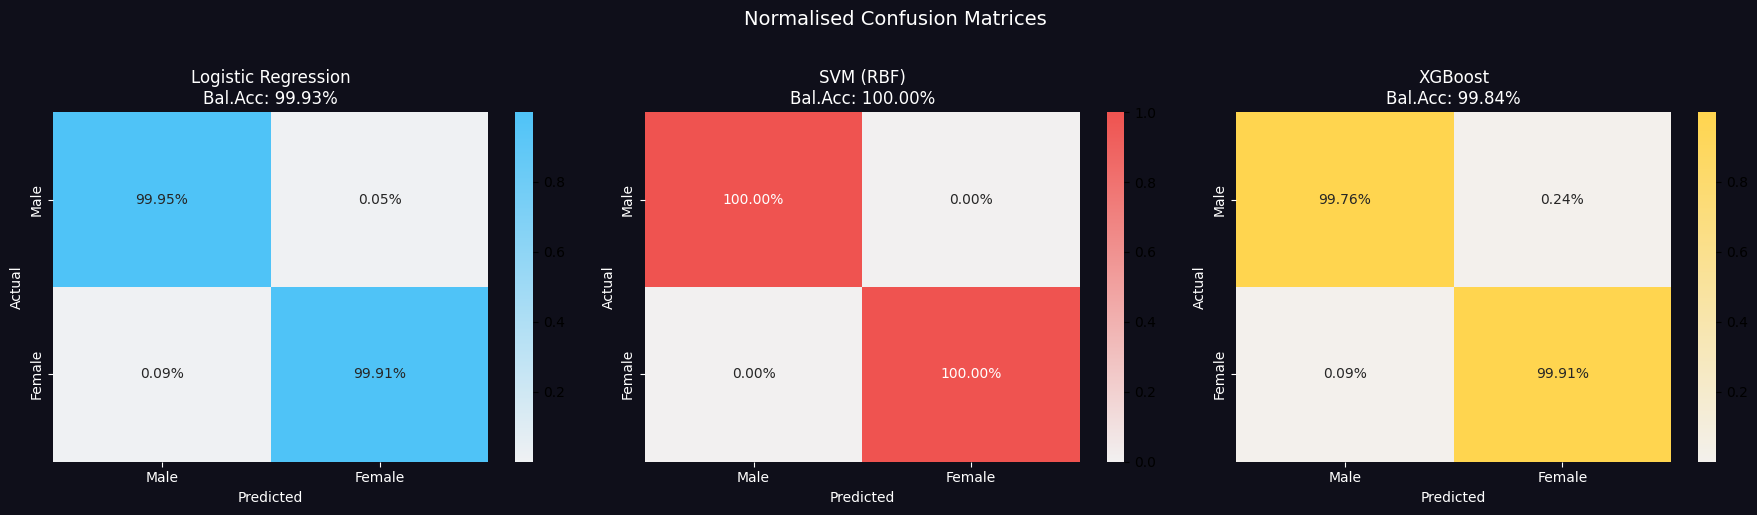

In [ ]:
# ── Cell 8: Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pred, color) in zip(axes, [
    ('Logistic Regression', lr_pred,  C['lr']),
    ('SVM (RBF)',           svm_pred, C['svm']),
    ('XGBoost',            xgb_pred, C['xgb']),
]):
    cm      = confusion_matrix(y_test, pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', ax=ax,
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['Male', 'Female'],
        yticklabels=['Male', 'Female'],
    )
    ax.set_facecolor('#0f0f1a')
    ax.tick_params(colors='white')
    ax.set_title(
        f'{name}\nBal.Acc: {balanced_accuracy_score(y_test, pred)*100:.2f}%',
        color='white'
    )
    ax.set_xlabel('Predicted', color='white')
    ax.set_ylabel('Actual',    color='white')

plt.suptitle('Normalised Confusion Matrices', color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

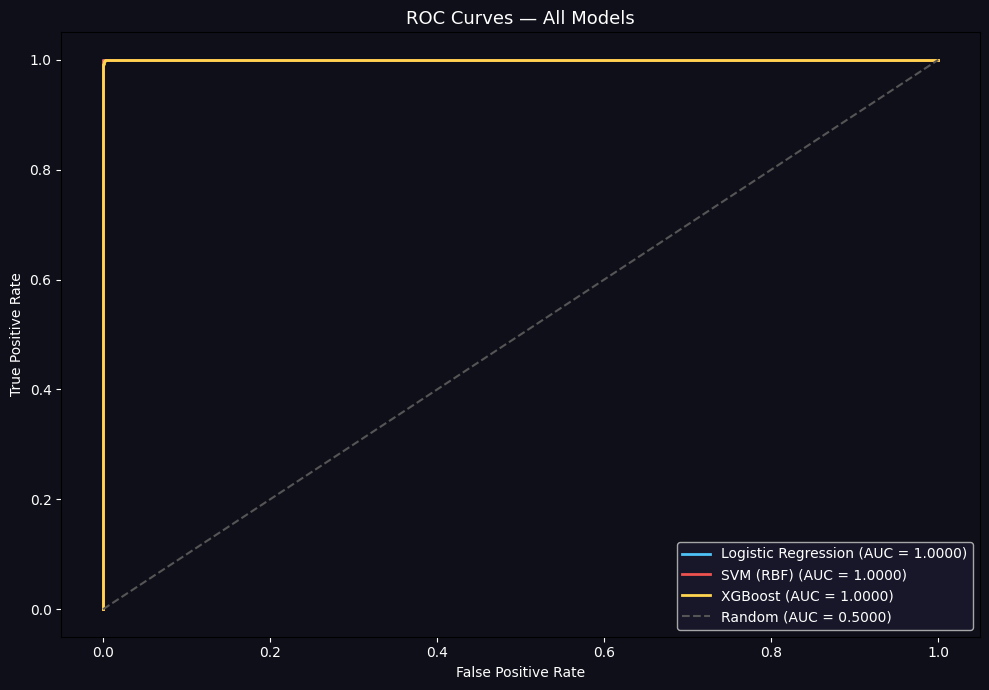

In [ ]:
# ── Cell 9: ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

for name, proba, color in [
    ('Logistic Regression', lr_proba,  C['lr']),
    ('SVM (RBF)',           svm_proba, C['svm']),
    ('XGBoost',            xgb_proba, C['xgb']),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

ax.plot([0, 1], [0, 1], color='#555', linestyle='--', label='Random (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate',  color='white')
ax.set_title('ROC Curves — All Models', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

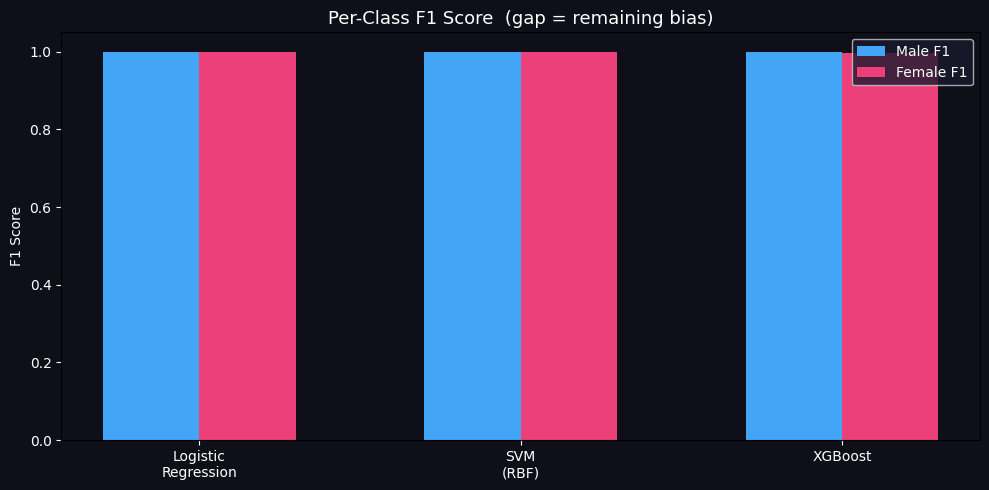

In [ ]:
# ── Cell 10: Per-Class F1 Bias Check ─────────────────────────────────────────
model_names = ['Logistic\nRegression', 'SVM\n(RBF)', 'XGBoost']
f1_male   = [results[k]['f1_male']   for k in results]
f1_female = [results[k]['f1_female'] for k in results]
x = np.arange(len(model_names))
w = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')
ax.bar(x - w/2, f1_male,   width=w, color=C['male'],   label='Male F1')
ax.bar(x + w/2, f1_female, width=w, color=C['female'], label='Female F1')
ax.set_xticks(x)
ax.set_xticklabels(model_names, color='white')
ax.tick_params(colors='white')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score', color='white')
ax.set_title('Per-Class F1 Score  (gap = remaining bias)', color='white', fontsize=13)
ax.legend(facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 11: 5-Fold Cross-Validation ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<6}  {'Mean Bal.Acc':>14}  {'Std':>8}")
print('─' * 35)
for name, model in [('LR', lr_model), ('SVM', svm_model), ('XGB', xgb_model)]:
    scores = cross_val_score(model, X_train, y_train_bal,
                             cv=cv, scoring='balanced_accuracy')
    print(f'{name:<6}  {scores.mean():>14.4f}  {scores.std():>8.4f}')

Model     Mean Bal.Acc       Std
───────────────────────────────────
LR              0.9997    0.0002
SVM             0.9999    0.0001
XGB             0.9989    0.0002


In [ ]:
# ── Cell 12: Save Models ──────────────────────────────────────────────────────
save_dir = '/content/drive/MyDrive/ML 2026/models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(lr_model,  f'{save_dir}/logistic_regression.pkl')
joblib.dump(svm_model, f'{save_dir}/svm_rbf.pkl')
joblib.dump(xgb_model, f'{save_dir}/xgboost.pkl')
joblib.dump(scaler,    f'{save_dir}/scaler.pkl')

print(f'✅ All models saved to: {save_dir}')
for fname in ['logistic_regression.pkl','svm_rbf.pkl','xgboost.pkl','scaler.pkl']:
    path = f'{save_dir}/{fname}'
    size = os.path.getsize(path) / 1024
    print(f'   📦 {fname:<30} ({size:.1f} KB)')

✅ All models saved to: /content/drive/MyDrive/ML 2026/models
   📦 logistic_regression.pkl        (1.3 KB)
   📦 svm_rbf.pkl                    (118.6 KB)
   📦 xgboost.pkl                    (252.2 KB)
   📦 scaler.pkl                     (1.9 KB)
